<a href="https://colab.research.google.com/github/raheelam98/DataAnalysis/blob/main/EDA/EDA_CheatSheet_RM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Session 03 - DA5_Missing_values_and_outliers

**RM Notes**

## **Unique Values**

### **Number of Unique Values in the specified column**

**`df['ColumnName'].nunique()`**

Returns the **number of unique values in the specified column** of a Pandas DataFrame.

**Use When:**

- You want to know how many distinct categories or values a column contains.
- It’s useful for categorical variables, especially during feature engineering (e.g., before encoding).


### **Count of Each Unique Value in a Series (column)**

**`df['ColumnName'].value_counts()`**

Returns a **count of each unique value in a Series (column)**, sorted in descending order by default.

**Use When:**

- You want to see how often each value occurs.
- Ideal for exploring data distribution and identifying common or rare categories.


In [1]:
import pandas as pd

df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Red', 'Green', 'Blue', 'Yellow']
})

# Count unique values in 'Color'
print(df['Color'].nunique())

## ['Red', 'Blue', 'Green', 'Yellow'] → 4 unique values

4


In [14]:
import pandas as pd

# Define the DataFrame only once
df = pd.DataFrame({
    'Color': ['Red', 'Blue', 'Red', 'Green', 'Blue', 'Yellow']
})

# Print value counts for the 'Color' column
print(df['Color'].value_counts())


Color
Red       2
Blue      2
Green     1
Yellow    1
Name: count, dtype: int64


In [11]:
import pandas as pd

df = pd.DataFrame({
    'City': ['Lahore', 'Karachi', 'Lahore', 'Islamabad', 'Karachi', 'Multan', 'Lahore']
})

print(df['City'].value_counts())


City
Lahore       3
Karachi      2
Islamabad    1
Multan       1
Name: count, dtype: int64


**RM Notes**

### **Count missing values in each column :**

**` df.isnull().sum() `**

**Explanation**

**` df.isnull() `** Returns a DataFrame of the same shape as df, where each cell is:

- True if the value is missing (NaN)
- False if the value is present



In [8]:
import pandas as pd

df = pd.DataFrame({
    'Name': ['Ali', 'Sara', None, 'Akram', 'Asma'],
    'Age': [25, None, 30, 50, None]
})

print(df.isnull())
# False if the value is present

    Name    Age
0  False  False
1  False   True
2   True  False
3  False  False
4  False   True


In [9]:
#% of missing values in a column
missing_values = df.isnull().sum() # how many missing values in the column

missing_percentage = (missing_values / len(df)) * 100 # len----> no of rows

print("\nMissing Value Percentage:\n\n", missing_percentage)

## % missing value-- no of missing value/ total data *100


Missing Value Percentage:

 Name    20.0
Age     40.0
dtype: float64


**RM Notes**

### **Histogram**

A **histogram displays** the distribution of a single numeric variable by showing the **frequency of values within continuous intervals** (bins).

- Single numerical variable: Yes — histograms are for one continuous variable.

- Frequency: Yes — it shows how often values occur within each interval.

- Continuous intervals (bins): Yes — the x-axis is split into equal-width ranges.


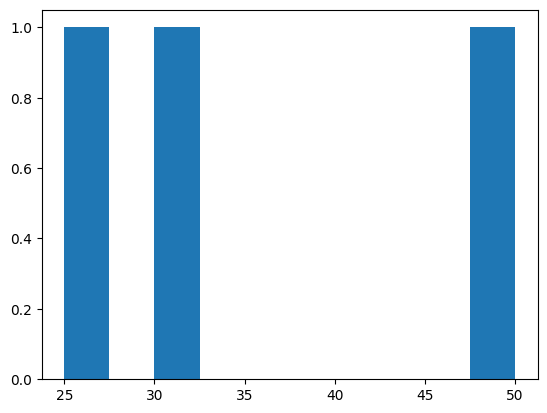

In [10]:
#fare and age imputation--- continous --- shape of the column
#histogram making
import matplotlib.pyplot as plt

plt.hist(df["Age"])
plt.show() # plot to show

**RM Notes**

### **Descriptive Statistics :  Mean - Median - Mode**

- **Mean**: Average of all values  
- **Median**: Middle value of ordered data  
- **Mode**: Most frequent value in the dataset


**` df['column_name'].mean() `**

**` df['column_name'].median() `**

**` df['column_name'].mode() `**

**RM Notes**

### **IQR (Interquartile Range)**

**IQR (Interquartile Range)** is a measure of statistical dispersion — it tells you how spread out the middle 50% of your data is.

|---------|==============|---------|
          
        Q1     IQR    Q3

**` Q1 = df['column_name'].quantile(0.25) `** returns the value at a given percentile of a numeric Series or column.

Calculate the Interquartile Range (IQR)

**` IQR = Q3 - Q1 `**

- **Q1** = 1st Quartile = 25th percentile — value below which 25% of the data falls  
- **Q3** = 3rd Quartile = 75th percentile — value below which 75% of the data falls

**Key Points :**

- IQR focuses on the **middle 50%** of your data (between Q1 and Q3)  
- It **ignores extreme values** (the lowest 25% and highest 25%)  
- A **larger IQR** means your data is more spread out  
- A **smaller IQR** means your data is more concentrated  

**Define the Bounds**

- **` Lower Bound = Q1 - 1.5 × IQR `**
- **` Upper Bound = Q3 + 1.5 × IQR `**

**Identify Outliers**

**` outliers = df['column_name'][(df['column_name'] < lower_bound) | (df['column_name'] > upper_bound)]  `**




In [15]:
import pandas as pd

# Sample dataset
data = pd.DataFrame({
    'Score': [10, 12, 14, 15, 18, 20, 22, 25, 27, 100]  # Notice the outlier at 100
})

# Step 1: Calculate Q1 and Q3
Q1 = data['Score'].quantile(0.25)
Q3 = data['Score'].quantile(0.75)

# Step 2: Calculate IQR
IQR = Q3 - Q1

# Step 3: Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 4: Identify outliers
outliers = data[(data['Score'] < lower_bound) | (data['Score'] > upper_bound)]

# Step 5: Print results
print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Bound :", lower_bound)
print("Upper Bound:", upper_bound)
print("\nOutliers:\n", outliers)


Q1 : 14.25
Q3 : 24.25
IQR : 10.0
Lower Bound : -0.75
Upper Bound:  39.25

Outliers :
    Score
9    100


#### **Dropping Columns / Rows in Pandas (Permanent Change)**

Pandas provides a method to remove rows or columns from a DataFrame using **` df.drop() `**.


**` df.drop('column_name', axis=1, inplace=True) `**

**Axis Parameter**

- `axis=0` → Drop **rows**  
- `axis=1` → Drop **columns**

**Inplace Parameter**

- `inplace=True` → Apply the change **permanently** to the original DataFrame  
- `inplace=False` → Return a **new DataFrame** without modifying the original (default behavior)

**Index of column_names in a Pandas DataFrame :**

**` df.columns `**

